In [6]:
from skyfield.api import load
import numpy as np
import matplotlib.pyplot as plt
from Final00_function import (
    calendar_to_jd, 
    jd_to_calendar, 
    julian_to_gregorian_preset,
    check_totality,
    check_totality_updated
)
from skyfield.api import load, wgs84

In [7]:
# 1. 【数据】输入数据参数

names = ["Zhangye", "Jiuquan", "Kuaiji"] # 张掖，酒泉，会稽
input_years = [118, 125, 139]
input_months = [9, 4, 1]
input_days = [3, 21, 18]
pos_longs = [100.45, 98 + 30 / 60, 120 + 35 / 60] 
pos_lats = [38.95, 39 + 44 / 60, 30] # 经度，纬度

# 设置统一的时间网格和Delta T扫描跨度

# 时间网格：寻找合适的日食时间
hour_min, hour_max = 5.0, 18.0
ut1_hours_coarse = np.arange(hour_min, hour_max, 0.5)
# 星历表加载
ts = load.timescale()
eph = load("de441.bsp")
sun, moon, earth = eph["sun"], eph["moon"], eph["earth"]


In [ ]:
# 2.【任务1】批量扫描，寻找日食约束下的 ΔT 范围
all_valid_dts = {}

for i in range(len(names)):
    name = names[i]
    # 转换历法
    g_year, g_month, g_day = julian_to_gregorian_preset(input_years[i], input_months[i], input_days[i])
    
    # 当前地点的观测站(郡治)
    qufu = earth + wgs84.latlon(pos_lats[i], pos_longs[i]) 
    
    # 获取默认时间模型的 ΔT 范围作为扫描基准
    ut1_hours_sample = np.arange(hour_min, hour_max, 30/60.0)
    t_temp_sample = ts.ut1(g_year, g_month, g_day, ut1_hours_sample)
    t_temp_skyfield_dt_min = min(t_temp_sample.delta_t)
    t_temp_skyfield_dt_max = max(t_temp_sample.delta_t)
    
    # 执行原代码定义的 check_totality 扫描（步长 20s）
    dt_range = np.arange(t_temp_skyfield_dt_min - 5000, t_temp_skyfield_dt_max + 5000, 20)
    valid_dts = []
    
    # 临时覆盖原 check_totality 所需的全局上下文变量（保持原函数不改动）
    year, m, d = g_year, g_month, g_day
    ut1_hours = ut1_hours_sample
    
    for d_t in dt_range:
        if check_totality_updated(d_t, ts, eph, qufu, sun, moon, g_year, g_month, g_day, ut1_hours_coarse):
            valid_dts.append(d_t)
            
    all_valid_dts[name] = valid_dts
    
    print(f"[{name}] Validation Finished.")
    if valid_dts:
        print(f"  Reproduced Delta T Range: {min(valid_dts):.2f} s ~ {max(valid_dts):.2f} s")
    else:
        print("  No totality region found in this range.")
    print("-" * 40)

[Zhangye] Validation Finished.
  Reproduced Delta T Range: 4218.10959817058 s ~ 14218.10959817058 s
----------------------------------------
[Jiuquan] Validation Finished.
  Reproduced Delta T Range: 5472.292660460596 s ~ 14152.292660460596 s
----------------------------------------
[Kuaiji] Validation Finished.
  Reproduced Delta T Range: 4016.5653057353484 s ~ 9836.565305735348 s
----------------------------------------


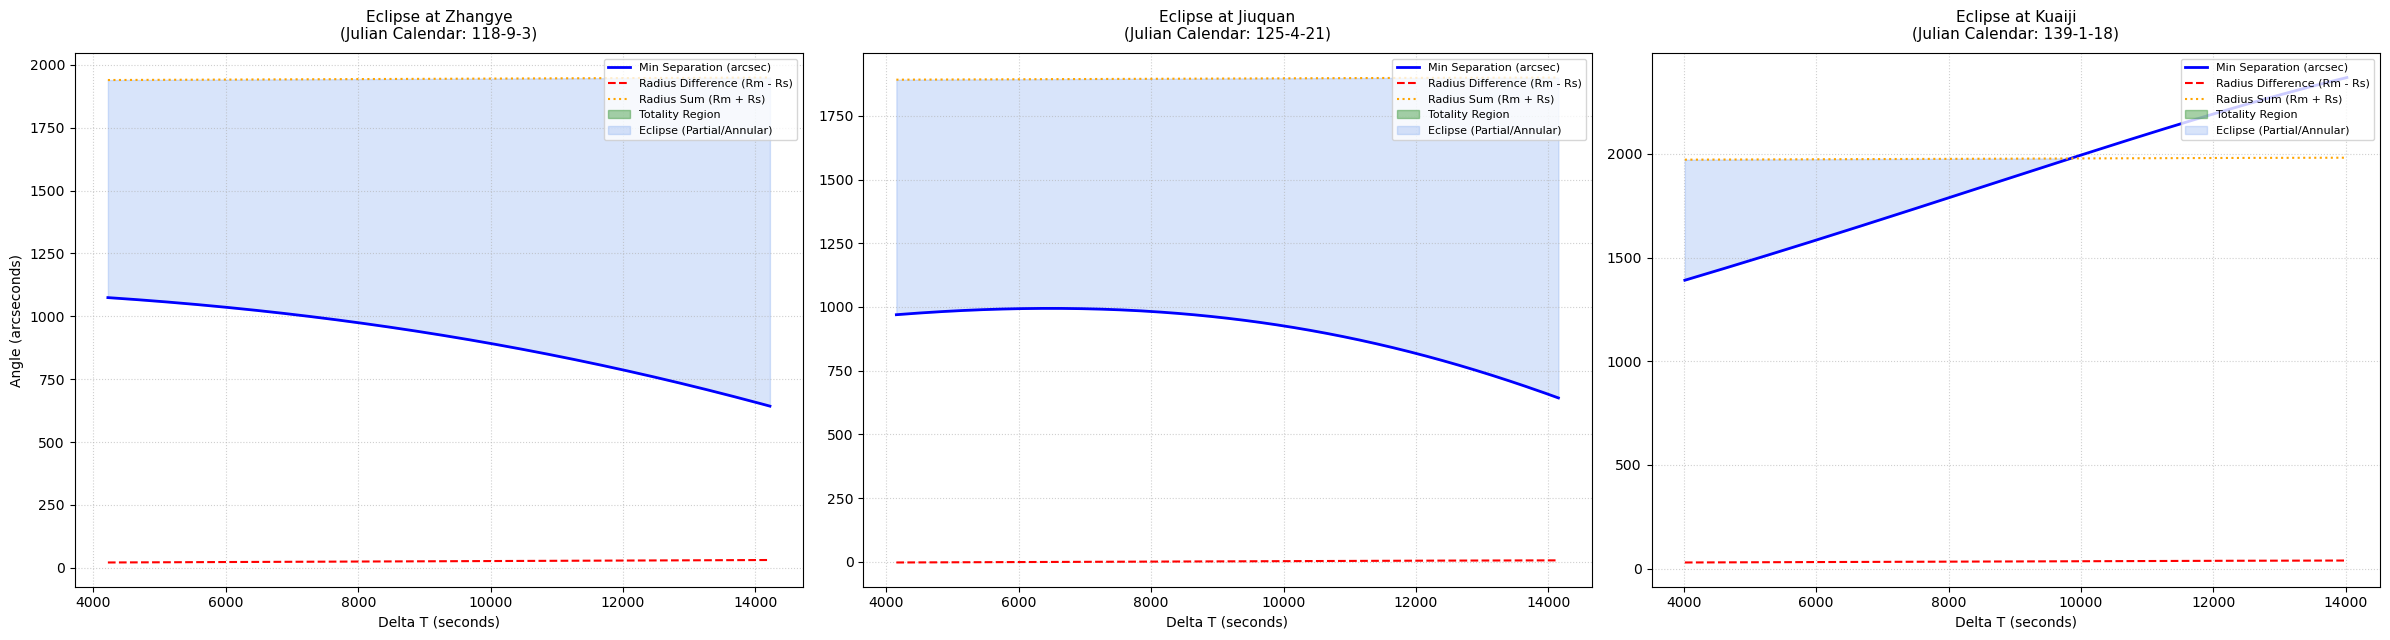

In [11]:
# 3. 任务 2：可视化输出（从粗糙到精确），展现日食变化
# 创建 1 行 3 列的画布
fig, axes = plt.subplots(1, 3, figsize=(24, 6.5), dpi=100)

for i in range(len(names)):
    name = names[i]
    ax = axes[i] # 获取当前子图句柄
    
    # 转换历法
    g_year, g_month, g_day = julian_to_gregorian_preset(input_years[i], input_months[i], input_days[i])
    qufu = earth + wgs84.latlon(pos_lats[i], pos_longs[i])
    
    # 计算扫描区间
    ut1_hours_sample = np.arange(hour_min, hour_max, 30/60.0)
    t_temp_sample = ts.ut1(g_year, g_month, g_day, ut1_hours_sample)
    t_temp_skyfield_dt_min = min(t_temp_sample.delta_t)
    t_temp_skyfield_dt_max = max(t_temp_sample.delta_t)
    
    dt_test_range = np.arange(t_temp_skyfield_dt_min - 5000, t_temp_skyfield_dt_max + 5000, 50)
    
    min_seps = []
    radius_diffs = []
    r_sun_list = []
    r_moon_list = []
    
    # 粗筛+细筛法绘图
    for d_t in dt_test_range:
        
        # --- 阶段 A：粗搜索（快速定位日月最接近的小时段） ---
        
        # 1. 生成当天粗颗粒度（半小时步长）的 UT1 时间对象
        t_coarse_temp = ts.ut1(g_year, g_month, g_day, ut1_hours_coarse)
        
        # 2. 注入当前测试的 Delta T，换算出对应的 TT 儒略日并构建时间对象
        jd_tt_coarse = t_coarse_temp.ut1 + d_t / 86400.0
        t_coarse = ts.tt_jd(jd_tt_coarse)
        t_coarse.delta_t = np.array([d_t] * len(jd_tt_coarse)) # 属性覆盖
        
        # 3. 计算粗筛下的日月视位置与角距离（单位：角秒）
        obs_s_c = qufu.at(t_coarse).observe(sun).apparent()
        obs_m_c = qufu.at(t_coarse).observe(moon).apparent()
        seps_coarse = obs_s_c.separation_from(obs_m_c).arcseconds()
        
        # 4. 寻找日月角距离最小的索引，锁定精搜的中心小时
        best_coarse_idx = np.argmin(seps_coarse)
        center_hour = ut1_hours_coarse[best_coarse_idx]
        
        
        # --- 阶段 B：高精度精搜索（中心时间前后 1 秒步长逼近） ---
        
        # 5. 在锁定的小时前后扩展 0.6 小时，建立 1 秒（1/3600 小时）步长网格
        ut1_hours_fine = np.arange(center_hour - 0.6, center_hour + 0.6, 1.0 / 3600.0)
        
        # 6. 重复换算过程，生成高精度的时间对象并注入 Delta T
        t_temp = ts.ut1(g_year, g_month, g_day, ut1_hours_fine)
        jd_tt = t_temp.ut1 + d_t / 86400.0
        t = ts.tt_jd(jd_tt)
        t.delta_t = np.array([d_t] * len(jd_tt))
        
        # 7. 计算 1 秒步长下的精确视位置、角距离以及日月视半径
        obs_s = qufu.at(t).observe(sun).apparent()
        obs_m = qufu.at(t).observe(moon).apparent()
        
        seps = obs_s.separation_from(obs_m).arcseconds()
        r_s = np.degrees(np.arcsin(695700.0 / obs_s.distance().km)) * 3600 # 太阳视半径
        r_m = np.degrees(np.arcsin(1737.4 / obs_m.distance().km)) * 3600  # 月球视半径
        
        
        # --- 阶段 C：提取并记录当前 Delta T 下的“食甚”最优值 ---
        
        # 8. 捕获角距离绝对最小（食甚）对应的索引
        best_idx = np.argmin(seps)
        
        # 9. 记录该状态下的核心几何参数，供后续条件判定和绘图
        min_seps.append(seps[best_idx])
        radius_diffs.append(r_m[best_idx] - r_s[best_idx]) # 半径差 (Rm - Rs)
        r_sun_list.append(r_s[best_idx])    
        r_moon_list.append(r_m[best_idx])
        
    min_seps = np.array(min_seps)
    radius_diffs = np.array(radius_diffs)
    sum_radii = np.array(r_sun_list) + np.array(r_moon_list)
    
    # 日食状态：本影/全食（绿色），其他日食（蓝色）
    is_total = (min_seps < radius_diffs) & (radius_diffs > 0)
    is_eclipse = min_seps < sum_radii
    is_eclipse_not_total = is_eclipse & ~is_total
    
    # 绘图
    ax.plot(dt_test_range, min_seps, label='Min Separation (arcsec)', color='blue', lw=2)
    ax.plot(dt_test_range, radius_diffs, label='Radius Difference (Rm - Rs)', color='red', linestyle='--')
    ax.plot(dt_test_range, sum_radii, label='Radius Sum (Rm + Rs)', color='orange', linestyle=':')
    
    # 区域填充
    ax.fill_between(dt_test_range, 0, min_seps, where=is_total, 
                    color='forestgreen', alpha=0.4, label='Totality Region')
    ax.fill_between(dt_test_range, min_seps, sum_radii, where=is_eclipse_not_total, 
                    color='cornflowerblue', alpha=0.25, label='Eclipse (Partial/Annular)')
    
    # setting
    ax.set_xlabel('Delta T (seconds)', fontsize=10)
    if i == 0:
        ax.set_ylabel('Angle (arcseconds)', fontsize=10)
    ax.set_title(f'Eclipse at {name}\n(Julian Calendar: {input_years[i]}-{input_months[i]}-{input_days[i]})', fontsize=11, pad=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right', fontsize=8, frameon=True)
    
    # 控制 Y 轴上下限
    y_min = np.min(radius_diffs) - 100
    y_max = (np.max(sum_radii) + 300) if np.any(is_eclipse) else (np.max(min_seps) + 200)
   # ax.ylim(y_min, y_max) if hasattr(ax, 'set_ylim') else ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

In [17]:
print(all_valid_dts.get(names[2], []))

[4016.5653057353484, 4036.5653057353484, 4056.5653057353484, 4076.5653057353484, 4096.565305735348, 4116.565305735348, 4136.565305735348, 4156.565305735348, 4176.565305735348, 4196.565305735348, 4216.565305735348, 4236.565305735348, 4256.565305735348, 4276.565305735348, 4296.565305735348, 4316.565305735348, 4336.565305735348, 4356.565305735348, 4376.565305735348, 4396.565305735348, 4416.565305735348, 4436.565305735348, 4456.565305735348, 4476.565305735348, 4496.565305735348, 4516.565305735348, 4536.565305735348, 4556.565305735348, 4576.565305735348, 4596.565305735348, 4616.565305735348, 4636.565305735348, 4656.565305735348, 4676.565305735348, 4696.565305735348, 4716.565305735348, 4736.565305735348, 4756.565305735348, 4776.565305735348, 4796.565305735348, 4816.565305735348, 4836.565305735348, 4856.565305735348, 4876.565305735348, 4896.565305735348, 4916.565305735348, 4936.565305735348, 4956.565305735348, 4976.565305735348, 4996.565305735348, 5016.565305735348, 5036.565305735348, 5056.56

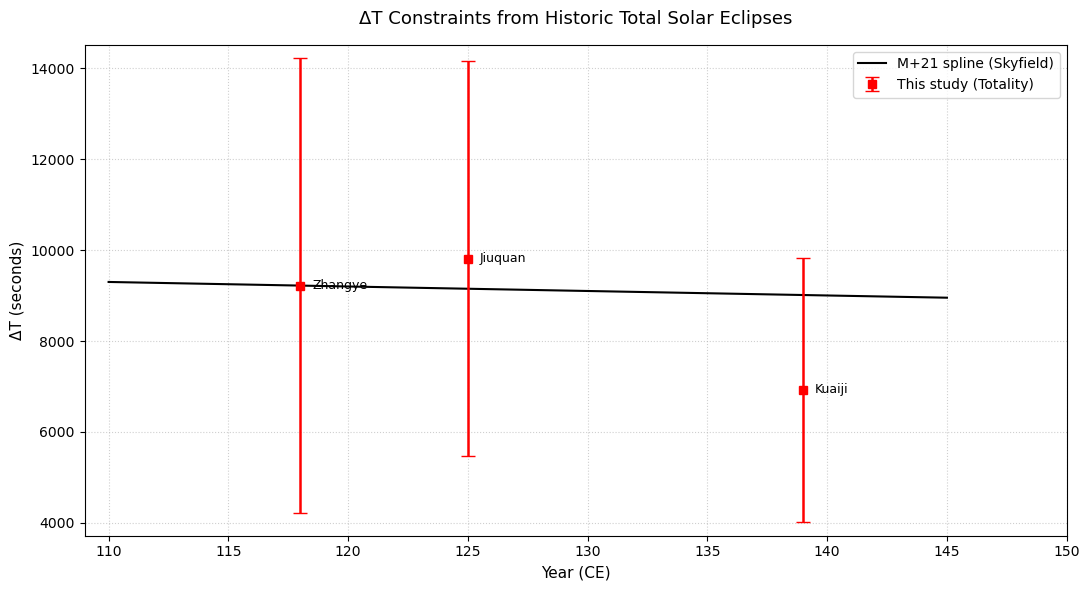

In [22]:
# 4. ΔT随年份变化图
# 对应年份：张掖(118), 酒泉(125), 会稽(139)
target_years = [118, 125, 139]
our_new_constraints = []

for idx, name in enumerate(names):    
    v_dts = all_valid_dts.get(name, [])
    if v_dts:
        lo = min(v_dts)
        hi = max(v_dts)
        our_new_constraints.append((target_years[idx], lo, hi, name))
    else:
        print(f"Warning: No valid Delta T found for {name}, skipping in plot.")


# 2. 用 Skyfield 获取公元 110-145 年的 M+21 ΔT 曲线

years_range = np.arange(110, 146, 1)        # 涵盖 118 到 139 年
t_demo = ts.ut1(years_range, 6, 1)          # 日期对 ΔT 趋势影响微乎其微
deltaT_M21_curve = t_demo.delta_t

# 3. 绘制误差棒对比图
plt.figure(figsize=(11, 6), dpi=100)

#  绘制黑色趋势线：M+21 spline 模型
plt.plot(years_range, deltaT_M21_curve, 'k-', linewidth=1.5, label="M+21 spline (Skyfield)")

# 循环绘制这三组历史事件的红色误差棒
for yr, lo, hi, label_name in our_new_constraints:
    mid = (lo + hi) / 2
    # 构造 matplotlib 误差棒要求的格式 [[下半截], [上半截]]
    y_err_range = [[mid - lo], [hi - mid]]
    
    # 用红色方块代表我们的复现区间
    plt.errorbar(yr, mid, yerr=y_err_range,
                 fmt='s', color='red', capsize=5, markersize=6,
                 lw=1.8, label='This study (Totality)' if yr == target_years[0] else "")
    
    # 在误差棒旁边用英文贴上地名标签，防止混淆
    plt.text(yr + 0.5, mid, f"{label_name}", 
             fontsize=9, color='black', va='center', ha='left')

# 绘图修饰
plt.xlabel('Year (CE)', fontsize=11)
plt.ylabel('ΔT (seconds)', fontsize=11)
plt.title('ΔT Constraints from Historic Total Solar Eclipses', fontsize=13, pad=15)
plt.legend(loc='upper right', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

all_vals = [val for item in our_new_constraints for val in (item[1], item[2])] # 留白
if all_vals:
    y_bottom = min(min(all_vals), min(deltaT_M21_curve)) - 300
    y_top = max(max(all_vals), max(deltaT_M21_curve)) + 300
    plt.ylim(y_bottom, y_top)

plt.xlim(min(years_range) - 1, max(years_range) + 5)
plt.tight_layout()
plt.show()